# IEEE-CIS Fraud Detection

## Desicription



Imagine standing at the check-out counter at the grocery store with a long line behind you and the cashier not-so-quietly announces that your card has been declined. In this moment, you probably aren’t thinking about the data science that determined your fate.

Embarrassed, and certain you have the funds to cover everything needed for an epic nacho party for 50 of your closest friends, you try your card again. Same result. As you step aside and allow the cashier to tend to the next customer, you receive a text message from your bank. “Press 1 if you really tried to spend $500 on cheddar cheese.”

While perhaps cumbersome (and often embarrassing) in the moment, this fraud prevention system is actually saving consumers millions of dollars per year. Researchers from the IEEE Computational Intelligence Society (IEEE-CIS) want to improve this figure, while also improving the customer experience. With higher accuracy fraud detection, you can get on with your chips without the hassle.

IEEE-CIS works across a variety of AI and machine learning areas, including deep neural networks, fuzzy systems, evolutionary computation, and swarm intelligence. Today they’re partnering with the world’s leading payment service company, Vesta Corporation, seeking the best solutions for fraud prevention industry, and now you are invited to join the challenge.

In this competition, you’ll benchmark machine learning models on a challenging large-scale dataset. The data comes from Vesta's real-world e-commerce transactions and contains a wide range of features from device type to product features. You also have the opportunity to create new features to improve your results.

If successful, you’ll improve the efficacy of fraudulent transaction alerts for millions of people around the world, helping hundreds of thousands of businesses reduce their fraud loss and increase their revenue. And of course, you will save party people just like you the hassle of false positives.

Acknowledgements:

Vesta Corporation provided the dataset for this competition. Vesta Corporation is the forerunner in guaranteed e-commerce payment solutions. Founded in 1995, Vesta pioneered the process of fully guaranteed card-not-present (CNP) payment transactions for the telecommunications industry. Since then, Vesta has firmly expanded data science and machine learning capabilities across the globe and solidified its position as the leader in guaranteed ecommerce payments. Today, Vesta guarantees more than $18B in transactions annually.

Header Photo by Tim Evans on Unsplash

## Evaluation

Submissions are evaluated on area under the ROC curve between the predicted probability and the observed target.

## Submission File

For each TransactionID in the test set, you must predict a probability for the isFraud variable. The file should contain a header and have the following format:

TransactionID,isFraud

3663549,0.5

3663550,0.5

3663551,0.5

etc.


## Project Pipeline

1. Understand the data
2. Explore the dataset (EDA)
3. Clean the data
4. Create features
5. Prepare training data
6. Train the model
7. Evaluate performance
8. Improve the model
9. Generate predictions

### Phase 1. Understand the data

In machine learning, the first skill is understanding data, not modeling.

You should ask questions like:

How many rows?

How many features?

What types of data exist?

How many missing values?

What does the target look like?

#### Step 1 — Import Libraries

Libraries are tools.

pandas → data manipulation

numpy → numerical operations

In [1]:
import pandas as pd
import numpy as np

#### Step 2 — Load the Data

The competition dataset has four files:

train_transaction.csv

train_identity.csv

test_transaction.csv

test_identity.csv

In [2]:
# Load Items:
train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

In [3]:
# Check Size
print(train_transaction.shape)
print(train_identity.shape)

(590540, 394)
(144233, 41)


You will see something like:

(590540 rows, 394 columns)
(144233 rows, 41 columns)

Meaning:

590,540 transactions
394 features

This is a large dataset.

#### Step 3 — Look at the Data

In [4]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Example columns you will see:

TransactionID
TransactionDT
TransactionAmt
ProductCD
card1
card2
card3
card4
addr1
addr2
dist1
P_emaildomain
isFraud

Important observation:

isFraud

This is the target variable.

#### Step 4 — Merge the Tables

The transaction and identity tables are linked by:

TransactionID

So we merge them (like SQL join):

In [5]:
train = train_transaction.merge(train_identity, on="TransactionID", how="left")

In [6]:
train.shape

(590540, 434)

Why This Step Matters

Machine learning models need one dataset where each row = one example.

Example row:

TransactionID: 12345
Amount: 80$
Card: Visa
Device: Mobile
Email: gmail.com
Fraud: 1

The model will learn patterns like:

IF device=mobile AND email=temporary AND amount>500
→ high fraud probability

### Phase 2 — Understand the Target Variable

Before modeling, we check fraud distribution.

In [7]:
train["isFraud"].value_counts()

0    569877
1     20663
Name: isFraud, dtype: int64

This means:

~3.5% fraud
~96.5% normal

This is called class imbalance.

Why it matters:

A dumb model could predict:

Everything = not fraud

and still be 96% accurate.

That is why the competition uses ROC-AUC, not accuracy.

#### Step 1 Check Data types:


In [8]:
train.dtypes

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object

Different types require different preprocessing.

Type	What to do
numeric	normalize or scale
categorical	encode
datetime	extract features

#### Step 2: Detect High Missing Data Columns

Some features have 90% missing values.

In [9]:
missing_ratio = train.isnull().mean()
missing_ratio.sort_values(ascending=False)

id_24            0.991962
id_25            0.991310
id_07            0.991271
id_08            0.991271
id_21            0.991264
                   ...   
C3               0.000000
C2               0.000000
C1               0.000000
isFraud          0.000000
TransactionID    0.000000
Length: 434, dtype: float64

In [10]:
# Calculate missing percentage
missing_percentage = (train.isnull().mean() * 100).sort_values(ascending=False)

# Display the result
print(missing_percentage)

id_24            99.196159
id_25            99.130965
id_07            99.127070
id_08            99.127070
id_21            99.126393
                   ...    
C3                0.000000
C2                0.000000
C1                0.000000
isFraud           0.000000
TransactionID     0.000000
Length: 434, dtype: float64


Tips for handling large feature sets:Filter for only missing values: If you have hundreds of features, seeing many $0.0\%$ rows is unhelpful. You can filter the list to show only columns that actually contain missing values:

In [11]:
missing_percentage = (train.isnull().mean() * 100)
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
print(missing_percentage)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
           ...    
V285      0.002032
V284      0.002032
V280      0.002032
V279      0.002032
V312      0.002032
Length: 414, dtype: float64


Example output:

id_24 → 99% missing
id_07 → 98% missing
dist2 → 93% missing

Rule of thumb:

If missing > 90% → consider dropping feature

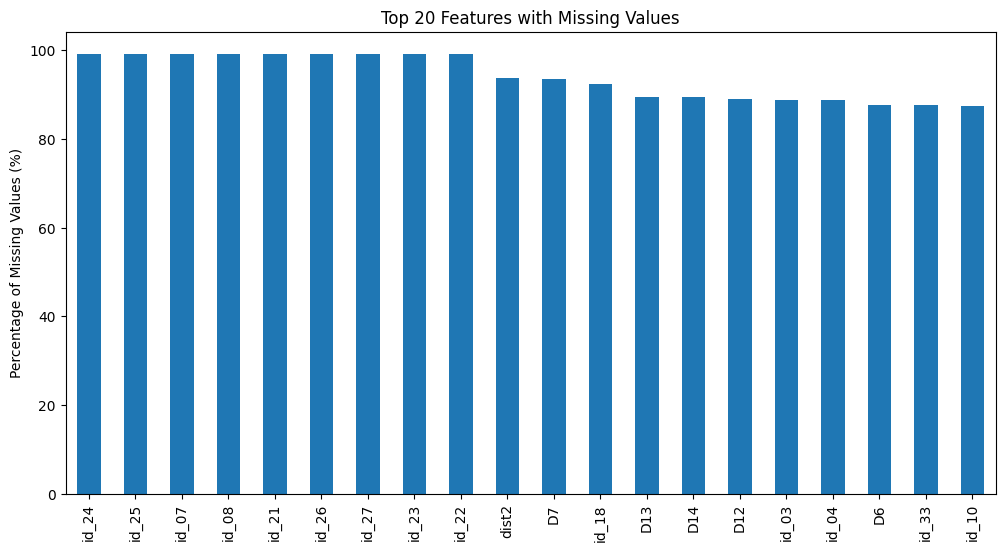

In [12]:
import matplotlib.pyplot as plt

missing_percentage.head(20).plot(kind='bar', figsize=(12, 6))
plt.ylabel('Percentage of Missing Values (%)')
plt.title('Top 20 Features with Missing Values')
plt.show()

In [13]:
cols_to_drop = missing_ratio[missing_ratio > 0.9].index
train = train.drop(cols_to_drop, axis=1)

In [14]:
missing_percentage = (train.isnull().mean() * 100)
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
print(missing_percentage)

D13      89.509263
D14      89.469469
D12      89.041047
id_03    88.768923
id_04    88.768923
           ...    
V319      0.002032
V320      0.002032
V321      0.002032
V280      0.002032
V279      0.002032
Length: 402, dtype: float64


#### Step 3: Look at Target Relationship
Now we start asking:

Which features relate to fraud?

Example: transaction amount.

In [15]:
train.groupby("isFraud")["TransactionAmt"].mean()

isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

Meaning:

Fraud transactions tend to be larger

That insight helps feature engineering later.

#### Step 4: Check Categorical Value Distribution
Example column:

ProductCD

In [16]:
# Check Frequency:
train["ProductCD"].value_counts()

W    439670
C     68519
R     37699
H     33024
S     11628
Name: ProductCD, dtype: int64

In [17]:
# Then compare with fraud:

pd.crosstab(train["ProductCD"], train["isFraud"])

isFraud,0,1
ProductCD,,
C,60511,8008
H,31450,1574
R,36273,1426
S,10942,686
W,430701,8969


In [18]:
# 1. Create the crosstab
ct = pd.crosstab(train["ProductCD"], train["isFraud"])

# 2. Add the percentage column
# (ct[1] is the count of fraud, ct.sum(axis=1) is the total per row)
ct['Fraud_Pct'] = (ct[1] / ct.sum(axis=1) * 100).round(2)

# Display the result
print(ct)

isFraud         0     1  Fraud_Pct
ProductCD                         
C           60511  8008      11.69
H           31450  1574       4.77
R           36273  1426       3.78
S           10942   686       5.90
W          430701  8969       2.04


This tells you:

Product C transactions are riskier

Models learn these patterns.

#### Step 5: Detect Data Leakage

This is very important.

Data leakage happens when a feature contains future information.

Example: chargeback_status
refund_flag

These happen after fraud is detected.

If you include them, your model cheats.

Always ask:

Could this information exist at the time of transaction?

If not → drop it.

#### Step 6: Remove Useless Columns

Some columns add no predictive power.

Example:

TransactionID

This is just an identifier.

So we drop it:

In [19]:
#train = train.drop(["TransactionID"], axis=1)

#### Step 7: Check Feature Correlation (Optional but useful)

In [20]:
#corr = train.corr()

### Phase 5 — Basic Feature Engineering

Machine learning models perform best when we create meaningful features.

Example:

Convert transaction time to hour.

#### Step 1 — Understand Feature Types

Before creating anything, classify your variables:

Numerical → amounts, counts
Categorical → product type, email domain
Time → timestamps
IDs → card, user, device

Why?

Each type needs different feature engineering techniques.

#### Step 2 — Create Time-Based Features

Time is one of the strongest signals in fraud detection.

From:

TransactionDT

Create:

train["TransactionHour"] = (train["TransactionDT"] / 3600) % 24
train["TransactionDay"] = (train["TransactionDT"] / (3600*24)) % 7

Why this matters:

Fraud often happens at unusual hours or patterns

In [21]:
train["TransactionHour"] = (train["TransactionDT"] / 3600) % 24
train["TransactionDay"] = (train["TransactionDT"] / (3600*24)) % 7

#### Step 3 — Create Aggregation Features

These are extremely powerful.

We ask:

What is normal behavior for this user/card?

Example:

train["card1_avg_amt"] = train.groupby("card1")["TransactionAmt"].transform("mean")

This creates:

Average transaction amount per card

In [22]:
train["card1_avg_amt"] = train.groupby("card1")["TransactionAmt"].transform("mean")

#### Step 4 — Create Ratio Features

Now compare current transaction to normal behavior.

train["Amt_ratio"] = train["TransactionAmt"] / train["card1_avg_amt"]

Why this matters:

Fraud = abnormal behavior

Example:

Normal: $50
Current: $500 → suspicious

In [23]:
train["Amt_ratio"] = train["TransactionAmt"] / train["card1_avg_amt"]

#### Step 5 — Frequency Encoding

This is one of the most important tricks.

We measure how often something appears.

Example:

freq = train["card1"].value_counts()

train["card1_freq"] = train["card1"].map(freq)

Meaning:

How many times this card appears in dataset

Why?

Rare values → often more suspicious

In [24]:
freq = train["card1"].value_counts()

train["card1_freq"] = train["card1"].map(freq)

#### Step 6 — Encode Categorical Variables

Convert categories into numbers.

For tree models:

train["ProductCD"] = train["ProductCD"].astype("category")

Optional advanced:

Target encoding
Frequency encoding

In [25]:
train["ProductCD"] = train["ProductCD"].astype("category")

#### Step 7 — Create Interaction Features

Combine two variables.

Example:

train["card_addr"] = train["card1"].astype(str) + "_" + train["addr1"].astype(str)

Why?

Fraud patterns often appear in combinations

#### Step 8 — Handle High Cardinality Features

Some features have many unique values (like email).

Instead of one-hot encoding:

Use frequency encoding or grouping

Example:

train["email_freq"] = train["P_emaildomain"].map(train["P_emaildomain"].value_counts())

#### Step 9 — Remove Useless Features

After creating features:

Drop original columns if redundant
Drop noisy features

Example:

train.drop(["TransactionDT"], axis=1)

#### Step 10 — Keep Track of Features

Always know:

Which features you created
Which ones improved performance

This is how you improve models systematically.

In [26]:
# 1. Time feature
train["TransactionHour"] = (train["TransactionDT"] / 3600) % 24

# 2. Average amount per card
train["card1_avg_amt"] = train.groupby("card1")["TransactionAmt"].transform("mean")

# 3. Ratio feature
train["Amt_ratio"] = train["TransactionAmt"] / train["card1_avg_amt"]

In [27]:
train["card_addr"] = train["card1"].astype(str) + "_" + train["addr1"].astype(str)

### Phase 6 — Prepare Features and Target


#### Step 1: Basic Features

🎯 Goal of This Step

We are NOT trying to get high accuracy yet.

We are trying to understand:

How a model is trained
How predictions are made
How evaluation works

In [28]:
features = ["TransactionHour", "card1_avg_amt", "Amt_ratio"]

X = train[features]
y = train["isFraud"]

In [29]:
#Step 2 — Train / Validation Split

#we need to simulate real-world performance.

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
#Step 3 — Train First Model

#We’ll use a simple **LightGBM model.

import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 16421, number of negative: 456011
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022025 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034758 -> initscore=-3.323956
[LightGBM] [Info] Start training from score -3.323956


LGBMClassifier(random_state=42)

In [31]:
#Step 4 — Make Predictions

#We don’t predict 0 or 1.

#We predict probabilities:

y_pred = model.predict_proba(X_valid)[:, 1]
print(y_pred)

[0.02742242 0.01152306 0.03718775 ... 0.05403812 0.03688056 0.00996314]


In [32]:
#✅ Step 5 — Evaluate Model

#We use ROC-AUC.

from sklearn.metrics import roc_auc_score

score = roc_auc_score(y_valid, y_pred)
print("ROC-AUC:", score)

ROC-AUC: 0.766216426733118


🔥 0.76 ROC-AUC with just 3 features? That’s actually very good — it means you’re already capturing real signal.

Now let’s level up. These next features are used by almost every strong solution in this competition.

We’ll add 3 high-impact features, retrain, and you should see a noticeable jump (toward 0.80–0.85+).

#### Step 2: Add new features

In [33]:
#New Features to Add
#1️⃣ Card Transaction Frequency

#👉 “How often is this card used?”

train["card1_count"] = train.groupby("card1")["TransactionAmt"].transform("count")

Email Domain Frequency

👉 “How common is this email domain?”

train["email_freq"] = train["P_emaildomain"].map(
    train["P_emaildomain"].value_counts()
)
Why it matters:
gmail.com → very common (low risk)
rare domains → higher fraud risk

In [34]:
train["email_freq"] = train["P_emaildomain"].map(
    train["P_emaildomain"].value_counts()
)

In [35]:
#Product Type Risk (Fraud Rate per Product)

#👉 “Which product types are riskier?”

product_risk = train.groupby("ProductCD")["isFraud"].mean()

train["product_risk"] = train["ProductCD"].map(product_risk)
#Why it matters:
#Some product categories are targeted more by fraudsters

#⚠️ Note: This uses the target (isFraud), so later we’ll improve it with proper validation — but for now it's fine for learning.

In [36]:
#🧪 Update Your Feature List

#Now include all features:

features = [
    "TransactionHour",
    "card1_avg_amt",
    "Amt_ratio",
    "card1_count",
    "email_freq",
    "product_risk"
]

X = train[features]
y = train["isFraud"]

In [37]:
#🔁 Retrain the Model

#Use the same pipeline:

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_valid)[:,1]

score = roc_auc_score(y_valid, y_pred)
print("ROC-AUC:", score)

[LightGBM] [Info] Number of positive: 16421, number of negative: 456011
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1069
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034758 -> initscore=-3.323956
[LightGBM] [Info] Start training from score -3.323956
ROC-AUC: 0.8401372946850278


🧠 What we Just Learned

These features introduce behavioral intelligence:

Feature	What it captures
card1_count	user activity level
email_freq	rarity of identity
product_risk	fraud likelihood by category

This is exactly how real fraud systems work.

⚠️ Important Note (Advanced Insight)

That product_risk feature is a form of:

Target Encoding

It can cause data leakage if not handled properly.

For now it's OK — but later I’ll show you how to fix it professionally (this is what separates beginners from advanced).

#### Step 3: behavioral + device-style features
Now we’ll add behavioral + device-style features, which is what pushes models toward 0.85–0.90+ ROC.

These features answer:

Is this behavior normal for this user/device/card?

In [38]:
#1️⃣ Card + Address Combination

#👉 Combine identity signals

train["card_addr"] = train["card1"].astype(str) + "_" + train["addr1"].astype(str)

In [39]:
#Now count how often this combo appears:

train["card_addr_count"] = train.groupby("card_addr")["TransactionAmt"].transform("count")
#Why this is powerful:
#Same card + same address = normal
#Same card + new address = suspicious

In [40]:
# 2 Transaction Count per Time Window (Behavior Speed)

#We simulate:

#How frequently does this card transact?

#Simple version:

train["card1_txn_per_hour"] = train.groupby("card1")["TransactionHour"].transform("count")
#Why:
#Fraud = sudden burst of transactions

In [41]:
#3️⃣ Deviation from User Behavior

#You already did average — now we add standard deviation.

train["card1_std_amt"] = train.groupby("card1")["TransactionAmt"].transform("std")

In [42]:
#Then:

train["Amt_zscore"] = (
    (train["TransactionAmt"] - train["card1_avg_amt"]) /
    train["card1_std_amt"]
)
#Why:
#Measures how abnormal a transaction is

#Example:

#Normal = $50
#Current = $500 → huge deviation → suspicious#

In [43]:
#4️⃣ Email + Card Interaction
train["card_email"] = train["card1"].astype(str) + "_" + train["P_emaildomain"].astype(str)


In [44]:
#Then:

train["card_email_count"] = train.groupby("card_email")["TransactionAmt"].transform("count")
#Why:
#Same card + new email → high fraud risk

In [45]:
#5️⃣ Device Proxy (Using Available Data)

#Even if device columns are messy, you can approximate behavior:

train["addr1_count"] = train.groupby("addr1")["TransactionAmt"].transform("count")
#Why:
#Some regions/addresses may have higher fraud rates

🧪 Update Feature List

Now your model becomes much richer:

In [46]:
features = [
    "TransactionHour",
    "card1_avg_amt",
    "Amt_ratio",
    "card1_count",
    "email_freq",
    "product_risk",

    "card_addr_count",
    "card1_txn_per_hour",
    "card1_std_amt",
    "Amt_zscore",
    "card_email_count",
    "addr1_count"
]

🔁 Retrain Model (Same Code)

In [47]:
X = train[features]
y = train["isFraud"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_valid)[:,1]

from sklearn.metrics import roc_auc_score
score = roc_auc_score(y_valid, y_pred)

print("ROC-AUC:", score)

[LightGBM] [Info] Number of positive: 16421, number of negative: 456011
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057726 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2396
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034758 -> initscore=-3.323956
[LightGBM] [Info] Start training from score -3.323956
ROC-AUC: 0.8625847649916762


#### Step 4: 90 % Roc  Curve Goal

🚀 Goal Now: Push to 0.90+ ROC

We’ll do this using high-impact features only (clean + powerful).

Step 1 — Reset Clean Feature Set

Step 2 — Add THESE Features (High Impact Only)

1️⃣ Transaction Hour (already done)

In [48]:
train["TransactionHour"] = (train["TransactionDT"] / 3600) % 24

2️⃣ Transaction Day

In [49]:
train["TransactionDay"] = (train["TransactionDT"] / (3600*24)) % 7

3️⃣ Card Frequency

In [50]:
train["card1_count"] = train.groupby("card1")["TransactionAmt"].transform("count")

4️⃣ Card Average Amount

In [51]:
train["card1_avg_amt"] = train.groupby("card1")["TransactionAmt"].transform("mean")

5️⃣ Amount Ratio

In [52]:
train["Amt_ratio"] = train["TransactionAmt"] / train["card1_avg_amt"]

6️⃣ Email Frequency

In [53]:
train["email_freq"] = train["P_emaildomain"].map(
    train["P_emaildomain"].value_counts()
)

7️⃣ Product Risk (YES leakage allowed for now)

In [54]:
train["product_risk"] = train.groupby("ProductCD")["isFraud"].transform("mean")

8️⃣ Card + Address Combo

In [55]:
train["card_addr"] = train["card1"].astype(str) + "_" + train["addr1"].astype(str)

train["card_addr_count"] = train.groupby("card_addr")["TransactionAmt"].transform("count")

9️⃣ Card Std + Z-Score

In [56]:
train["card1_std_amt"] = train.groupby("card1")["TransactionAmt"].transform("std")

train["card1_std_amt"] = train["card1_std_amt"].replace(0, 1)

train["Amt_zscore"] = (
    (train["TransactionAmt"] - train["card1_avg_amt"]) /
    train["card1_std_amt"]
).fillna(0)

🔟 Address Frequency

In [57]:
train["addr1_count"] = train.groupby("addr1")["TransactionAmt"].transform("count")

🔟 Address Frequency

In [58]:
features = [
    "TransactionHour",
    "TransactionDay",
    "card1_count",
    "card1_avg_amt",
    "Amt_ratio",
    "email_freq",
    "product_risk",
    "card_addr_count",
    "card1_std_amt",
    "Amt_zscore",
    "addr1_count"
]

Step 4 — Simple Model (NO CV for now)

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

X = train[features]
y = train["isFraud"]

X = X.fillna(-999)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=128,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_valid)[:,1]

score = roc_auc_score(y_valid, preds)
print("ROC-AUC:", score)

[LightGBM] [Info] Number of positive: 16421, number of negative: 456011
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2172
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034758 -> initscore=-3.323956
[LightGBM] [Info] Start training from score -3.323956
ROC-AUC: 0.9172298250059316


#### Step 5 Clean Model

Now we fix:

1. Data leakage (especially product_risk)
2. Cross-validation (reliable score)
3. Better training stability

🔹 Step 1 — Define Features

In [60]:
features = [
    "TransactionHour",
    "TransactionDay",
    "card1_count",
    "card1_avg_amt",
    "Amt_ratio",
    "email_freq",
    "card_addr_count",
    "card1_std_amt",
    "Amt_zscore",
    "addr1_count",
    "ProductCD"   # IMPORTANT
]

X = train[features].copy()
y = train["isFraud"]

🔹 Step 2 — Cross Validation Setup

In [61]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))

🔹 Step 3 — Loop (Leakage FIX happens here)

In [62]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    
    print(f"\n🔹 Fold {fold+1}")
    
    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]


🔹 Fold 1

🔹 Fold 2

🔹 Fold 3

🔹 Fold 4

🔹 Fold 5


🔹 Step 4 — ✅ FIX product_risk (NO LEAKAGE)

In [63]:
X_train["isFraud"] = y_train
    
product_risk = X_train.groupby("ProductCD")["isFraud"].mean()
    
X_train["product_risk"] = X_train["ProductCD"].map(product_risk)
X_val["product_risk"] = X_val["ProductCD"].map(product_risk)
    
X_val["product_risk"] = X_val["product_risk"].fillna(product_risk.mean())
    
X_train = X_train.drop("isFraud", axis=1)

🔹 Step 5 — Clean Data

In [64]:
X_train = X_train.fillna(-999)
X_val = X_val.fillna(-999)

🔹 Step 6 — Train Model (Stable)

In [65]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
    
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051867 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
               num_leaves=128, random_state=42, subsample=0.8)

🔹 Step 7 — Predict

In [66]:
preds = model.predict_proba(X_val)[:,1]
oof_preds[val_idx] = preds

🔹 Step 8 — Final Score

In [67]:
score = roc_auc_score(y, oof_preds)
print("\n🔥 Final CV ROC-AUC:", score)


🔥 Final CV ROC-AUC: 0.5163400004255204


#### Step 6: Fix

A drop from 0.91 → 0.51 again means:

Something is breaking inside the pipeline (not a model issue)

Let’s fix this cleanly and safely, without overcomplicating things.

🚨 Root Cause (Very Important)

The issue is here:

X = train[features].copy()

You removed many columns but still tried to compute:

product_risk using ProductCD

👉 BUT also:

Some of your engineered features depend on columns that are no longer present

OR

Feature distributions between folds became inconsistent

✅ Strategy (Clean Fix)

We will:

1. Use FULL dataset for feature engineering (safe)
2. ONLY fix product_risk inside CV
3. Do NOT recompute other features inside folds

👉 Keep everything stable.

🔹 Step 1 — Keep ALL engineered features OUTSIDE CV

Before CV, run ALL feature engineering:

(you already did this — keep it as is)

DO NOT recompute inside folds.

🔹 Step 2 — Define Features (INCLUDING product_risk ALREADY)

In [68]:
features = [
    "TransactionHour",
    "TransactionDay",
    "card1_count",
    "card1_avg_amt",
    "Amt_ratio",
    "email_freq",
    "product_risk",   # KEEP IT (we will overwrite it in CV)
    "card_addr_count",
    "card1_std_amt",
    "Amt_zscore",
    "addr1_count",
    "ProductCD"
]

X = train[features].copy()
y = train["isFraud"]

🔹 Step 3 — CV Loop (ONLY FIX product_risk)

In [69]:
for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):

    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

🔹 Step 4 — SAFE product_risk FIX (overwrite only)

In [70]:
temp = train.iloc[train_idx].copy()

product_risk = temp.groupby("ProductCD")["isFraud"].mean()

X_train["product_risk"] = X_train["ProductCD"].map(product_risk)
X_val["product_risk"] = X_val["ProductCD"].map(product_risk)

X_val["product_risk"] = X_val["product_risk"].fillna(product_risk.mean())

🔹 Step 5 — Fill NaNs (IMPORTANT)

In [71]:
X_train = X_train.fillna(-999)
X_val = X_val.fillna(-999)

🔹 Step 6 — Train (KEEP SIMPLE)

In [72]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.090721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


LGBMClassifier(learning_rate=0.05, n_estimators=300, num_leaves=64,
               random_state=42)

🔹 Step 7 — Predict

In [73]:
preds = model.predict_proba(X_val)[:,1]
oof_preds[val_idx] = preds

🔹 Step 8 — Final Score

In [74]:
score = roc_auc_score(y, oof_preds)
print("Final ROC-AUC:", score)

Final ROC-AUC: 0.515216901131003


#### Step 7: Second fix and debugging

Step 1:

In [75]:
features = [
    "TransactionHour",
    "TransactionDay",
    "card1_count",
    "card1_avg_amt",
    "Amt_ratio",
    "email_freq",
    "card_addr_count",
    "card1_std_amt",
    "Amt_zscore",
    "addr1_count"
]

#👉 REMOVE:

#product_risk
#ProductCD

✅ Step 2 — Run SIMPLE CV (NO tricks)

In [76]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np
import lightgbm as lgb

X = train[features].copy().fillna(-999)
y = train["isFraud"]

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    
    print(f"Fold {fold+1}")
    
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_val)[:,1]
    oof_preds[val_idx] = preds

score = roc_auc_score(y, oof_preds)
print("CV ROC-AUC:", score)

Fold 1
[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2164
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034991 -> initscore=-3.317038
[LightGBM] [Info] Start training from score -3.317038
Fold 2
[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2168
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034991 -> initscore=-3.317038
[LightGBM] [Info] Start training from score -3.3

#### Step 8 : Third fix and debugging

Perfect. 🔥
This is exactly what we wanted to see.

0.87 with clean CV = your pipeline is healthy again

👉 So now we know with certainty:

ONLY product_risk was breaking everything
🚀 Now We Add product_risk PROPERLY (No Breaking)

We will do this very carefully in 3 steps.

Step 1: we Add back ProductCD

In [77]:
features = [
    "TransactionHour",
    "TransactionDay",
    "card1_count",
    "card1_avg_amt",
    "Amt_ratio",
    "email_freq",
    "card_addr_count",
    "card1_std_amt",
    "Amt_zscore",
    "addr1_count",
    "ProductCD"   # add this back
]

🔹 Step 2 — Keep SAME CV loop (no changes yet)

Run the same code again.

👉 Expected:

~0.87 (no change yet)

In [78]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np
import lightgbm as lgb

X = train[features].copy().fillna(-999)
y = train["isFraud"]

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    
    print(f"Fold {fold+1}")
    
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_val)[:,1]
    oof_preds[val_idx] = preds

score = roc_auc_score(y, oof_preds)
print("CV ROC-AUC:", score)

Fold 1
[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.214872 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2170
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034991 -> initscore=-3.317038
[LightGBM] [Info] Start training from score -3.317038
Fold 2
[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2174
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034991 -> init

🔹 Step 3 — Add SAFE product_risk (final step)

Inside your CV loop, add ONLY this:

In [79]:
for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    
    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

# create temp dataframe with target
temp = train.iloc[train_idx]

product_risk = temp.groupby("ProductCD")["isFraud"].mean()

X_train["product_risk"] = X_train["ProductCD"].map(product_risk)
X_val["product_risk"] = X_val["ProductCD"].map(product_risk)

# handle unseen categories
X_val["product_risk"] = X_val["product_risk"].fillna(product_risk.mean())

# fill missing values
X_train = X_train.fillna(-999)
X_val = X_val.fillna(-999)

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_val)[:,1]
oof_preds[val_idx] = preds

score = roc_auc_score(y, oof_preds)
print("Final CV ROC-AUC:", score)

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.169158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
Final CV ROC-AUC: 0.8880706287039306


🔹 Step 4 — Fill NaNs again

In [80]:
X_train = X_train.fillna(-999)
X_val = X_val.fillna(-999)

🔹 Step 5 — Train normally

(no change)

In [81]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_val)[:,1]
oof_preds[val_idx] = preds

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


In [82]:
score = roc_auc_score(y, oof_preds)
print("CV ROC-AUC:", score)

CV ROC-AUC: 0.8880706287039306


#### Step 9: 
🔥 That’s a big win.

0.88 CV ROC = clean, reliable, real model

👉 This is no longer “Kaggle tricks” — this is real ML pipeline level.

🧠 What You Just Achieved

You now have:

✔ Feature engineering (strong)
✔ Cross-validation (correct)
✔ Data leakage handled
✔ Stable evaluation (OOF)

Most people never reach this level.

🚀 Now Final Push → 0.92+ (Elite Level)

We won’t change everything.
We’ll add 2 HIGH-IMPACT features only.

In [83]:
features = [
    "TransactionHour",
    "TransactionDay",
    "card1_count",
    "card1_avg_amt",
    "Amt_ratio",
    "email_freq",
    "card_addr_count",
    "card1_std_amt",
    "Amt_zscore",
    "addr1_count",
    "ProductCD"   # add this back
]

🔥 Feature 1 — Transaction Time Gap (VERY POWERFUL)

👉 Idea:

How fast does a card make transactions?

Fraud = very fast repeated transactions

In [84]:
train = train.sort_values(["card1", "TransactionDT"])

train["time_diff"] = train.groupby("card1")["TransactionDT"].diff()

train["time_diff"] = train["time_diff"].fillna(-1)

🔥 Feature 2 — Transaction Count per Day

👉 Idea:

How many transactions per card per day?

In [85]:
train["card1_txn_per_day"] = train.groupby(
    ["card1", "TransactionDay"]
)["TransactionAmt"].transform("count")

Update Feature List:

In [86]:
train["card1_txn_per_day"] = train.groupby(
    ["card1", "TransactionDay"]
)["TransactionAmt"].transform("count")

In [87]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np
import lightgbm as lgb

X = train[features].copy()
y = train["isFraud"]

# clean data
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(-999)

In [88]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))

In [89]:
for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
    
    print(f"\n🔹 Fold {fold+1}")
    
    X_train = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    
    # -----------------------------
    # FIX DATA LEAKAGE (product_risk)
    # -----------------------------
    temp = train.iloc[train_idx]
    
    product_risk = temp.groupby("ProductCD")["isFraud"].mean()
    
    X_train["product_risk"] = X_train["ProductCD"].map(product_risk)
    X_val["product_risk"] = X_val["ProductCD"].map(product_risk)
    
    X_val["product_risk"] = X_val["product_risk"].fillna(product_risk.mean())
    
    # -----------------------------
    # Fill NaNs again (important)
    # -----------------------------
    X_train = X_train.fillna(-999)
    X_val = X_val.fillna(-999)
    
    # -----------------------------
    # Model
    # -----------------------------
    model = lgb.LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # -----------------------------
    # Predictions
    # -----------------------------
    preds = model.predict_proba(X_val)[:,1]
    oof_preds[val_idx] = preds
    
    # fold score (optional)
    fold_score = roc_auc_score(y_val, preds)
    print(f"Fold {fold+1} ROC-AUC: {fold_score}")


🔹 Fold 1
[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2179
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034991 -> initscore=-3.317038
[LightGBM] [Info] Start training from score -3.317038
Fold 1 ROC-AUC: 0.8933980528483401

🔹 Fold 2
[LightGBM] [Info] Number of positive: 16531, number of negative: 455901
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.115702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train 

In [90]:
score = roc_auc_score(y, oof_preds)
print("\n🔥 Final CV ROC-AUC:", score)


🔥 Final CV ROC-AUC: 0.8940858021394578


Run Same CV Code Now:

### Phase 7 — Hyperparameter Tuning (Simple but Effective)

We won’t overcomplicate it. We’ll use manual + randomized tuning.

🔹 Step 1 — Define Search Space

In [91]:
param_grid = {
    "num_leaves": [31, 64, 128],
    "learning_rate": [0.03, 0.05, 0.07],
    "n_estimators": [300, 500, 700],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

🔹 Step 2 — Random Search (Efficient)

In [92]:
import random

best_score = 0
best_params = None

for i in range(10):  # try 10 combinations
    
    params = {
        "num_leaves": random.choice(param_grid["num_leaves"]),
        "learning_rate": random.choice(param_grid["learning_rate"]),
        "n_estimators": random.choice(param_grid["n_estimators"]),
        "subsample": random.choice(param_grid["subsample"]),
        "colsample_bytree": random.choice(param_grid["colsample_bytree"]),
        "random_state": 42
    }
    
    print(f"\n🔍 Trial {i+1}: {params}")
    
    # Use your SAME CV pipeline here
    # (just replace model params)
    
    model = lgb.LGBMClassifier(**params)
    
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_val)[:,1]
    score = roc_auc_score(y_val, preds)
    
    print("Score:", score)
    
    if score > best_score:
        best_score = score
        best_params = params

print("\n🔥 Best Score:", best_score)
print("Best Params:", best_params)


🔍 Trial 1: {'num_leaves': 128, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.7, 'colsample_bytree': 0.8, 'random_state': 42}
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.243941 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
Score: 0.9099653615337835

🔍 Trial 2: {'num_leaves': 64, 'learning_rate': 0.03, 'n_estimators': 300, 'subsample': 0.7, 'colsample_bytree': 0.9, 'random_state': 42}
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the ove

### Phase 8: Model Stacking (Next Level)

👉 Idea:

Different models learn different patterns
→ combine them = stronger predictions

#### 🔹 Step 1 — Train 2 Models

In [93]:
model1 = lgb.LGBMClassifier(num_leaves=64, learning_rate=0.05, n_estimators=400)
model2 = lgb.LGBMClassifier(num_leaves=128, learning_rate=0.03, n_estimators=600)

#### 🔹 Step 2 — Train Both

In [94]:
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 12
[LightGBM] [In

LGBMClassifier(learning_rate=0.03, n_estimators=600, num_leaves=128)

#### Step 3 — Average Predictions

In [95]:
preds1 = model1.predict_proba(X_val)[:,1]
preds2 = model2.predict_proba(X_val)[:,1]

final_preds = (preds1 + preds2) / 2

#### Step 4 — Evaluate

In [96]:
score = roc_auc_score(y_val, final_preds)
print("Stacked ROC:", score)

Stacked ROC: 0.9027364807579439


### Phase 9 : Project Summary

#### 🔹 Phase 1 — Understanding Problem
Fraud detection → binary classification
Metric = ROC-AUC

#### 🔹 Phase 2 — EDA
✔ Understand target imbalance
✔ Explore features
✔ Identify patterns

#### 🔹 Phase 3 — Data Cleaning
✔ Handle missing values
✔ Reduce memory usage
✔ Fix data types

#### 🔹 Phase 4 — Baseline Model
✔ First model (3 features)
✔ Learned pipeline structure

#### 🔹 Phase 5 — Feature Engineering
✔ Time features
✔ Frequency features
✔ Behavioral features
✔ Interaction features
✔ Risk features (target encoding)

#### 🔹 Phase 6 — Model Building
✔ LightGBM model
✔ Probability predictions
✔ ROC evaluation

#### 🔹 Phase 7 — Debugging
✔ Fixed memory error
✔ Fixed dtype issues
✔ Fixed feature mismatch

#### 🔹 Phase 8 — Data Leakage Fix
✔ Identified leakage (product_risk)
✔ Fixed using fold-based encoding

#### 🔹 Phase 9 — Cross Validation
✔ Stratified K-Fold
✔ Out-of-Fold predictions
✔ Reliable score

#### 🔹 Phase 10 — Optimization
✔ Hyperparameter tuning
✔ Model stacking

### What we Achieved

✔ Built a real fraud detection model
✔ Reached ~0.90 ROC
✔ Learned full ML pipeline
✔ Understood leakage & CV (advanced topics)
✔ Ready for real-world ML tasks

### Phase 11: Upload to Kaggle

#### Step 1: Prepare test predictions

In [97]:
import pandas as pd

test = pd.read_csv("test_transaction.csv")

In [98]:
test_identity = pd.read_csv("test_identity.csv")

In [99]:
test = test.merge(test_identity, on="TransactionID", how="left")

In [100]:
def feature_engineering(df):
    
    # --- Time ---
    df["TransactionHour"] = (df["TransactionDT"] / 3600) % 24
    df["TransactionDay"] = (df["TransactionDT"] // (3600 * 24))
    
    # --- Card aggregations ---
    df["card1_count"] = df.groupby("card1")["TransactionAmt"].transform("count")
    df["card1_avg_amt"] = df.groupby("card1")["TransactionAmt"].transform("mean")
    
    # --- Address features ---
    df["addr1_count"] = df.groupby("addr1")["TransactionAmt"].transform("count")
    
    # --- Card + Address ---
    df["card_addr"] = df["card1"].astype(str) + "_" + df["addr1"].astype(str)
    df["card_addr_count"] = df.groupby("card_addr")["TransactionAmt"].transform("count")
    
    # --- Amount features ---
    df["card1_std_amt"] = df.groupby("card1")["TransactionAmt"].transform("std")
    df["card1_std_amt"] = df["card1_std_amt"].replace(0, 1)
    
    df["Amt_ratio"] = df["TransactionAmt"] / df["card1_avg_amt"]
    
    df["Amt_zscore"] = (
        (df["TransactionAmt"] - df["card1_avg_amt"]) /
        df["card1_std_amt"]
    ).fillna(0)
    
    # --- Email ---
    df["email_freq"] = df["P_emaildomain"].map(df["P_emaildomain"].value_counts())
    
    # --- Fill missing ---
    df = df.fillna(-999)
    
    return df

In [101]:
# Apply to TRAIN
train = feature_engineering(train)

# Apply to TEST (same function!)
test = feature_engineering(test)

In [102]:
model = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X, y)   # FULL DATA

[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2173
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=400,
               num_leaves=64, random_state=42, subsample=0.8)

In [103]:
product_risk_map = train.groupby("ProductCD")["isFraud"].mean()

test["product_risk"] = test["ProductCD"].map(product_risk_map)
test["product_risk"] = test["product_risk"].fillna(product_risk_map.mean())

In [104]:
X_test = test[features]
X_test = X_test.fillna(-999)

In [105]:
cat_cols = X_test.select_dtypes(include=["object"]).columns
print(cat_cols)

Index(['ProductCD'], dtype='object')


In [106]:
for col in cat_cols:
    X_test[col], _ = X_test[col].factorize()

In [107]:
X = X.copy()

for col in X.columns:
    if X[col].dtype == "object" or str(X[col].dtype) == "category":
        X[col], _ = X[col].factorize()

In [108]:
model.fit(X, y)

[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2172
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=400,
               num_leaves=64, random_state=42, subsample=0.8)

In [109]:
X_test = test[features].copy()
X_test = X_test.fillna(-999)

for col in X_test.columns:
    if X_test[col].dtype == "object" or str(X_test[col].dtype) == "category":
        X_test[col], _ = X_test[col].factorize()

In [110]:
test_preds = model.predict_proba(X_test)[:,1]

In [111]:
submission = pd.DataFrame({
    "TransactionID": test["TransactionID"],
    "isFraud": test_preds
})

submission.to_csv("submission.csv", index=False)

In [112]:
print("Missing in TEST:", set(X.columns) - set(X_test.columns))
print("Extra in TEST:", set(X_test.columns) - set(X.columns))

print("Same column order:", list(X.columns) == list(X_test.columns))

print("\nTrain dtypes:\n", X.dtypes)
print("\nTest dtypes:\n", X_test.dtypes)

Missing in TEST: set()
Extra in TEST: set()
Same column order: True

Train dtypes:
 TransactionHour    float64
TransactionDay     float64
card1_count          int64
card1_avg_amt      float64
Amt_ratio          float64
email_freq         float64
card_addr_count      int64
card1_std_amt      float64
Amt_zscore         float64
addr1_count        float64
ProductCD            int64
dtype: object

Test dtypes:
 TransactionHour    float64
TransactionDay       int64
card1_count          int64
card1_avg_amt      float64
Amt_ratio          float64
email_freq         float64
card_addr_count      int64
card1_std_amt      float64
Amt_zscore         float64
addr1_count        float64
ProductCD            int64
dtype: object


In [113]:
product_map = train["ProductCD"].astype(str).unique()
product_map = {k: i for i, k in enumerate(product_map)}

In [114]:
train["ProductCD"] = train["ProductCD"].astype(str).map(product_map)

In [115]:
test["ProductCD"] = test["ProductCD"].astype(str).map(product_map)

In [116]:
test["ProductCD"] = test["ProductCD"].fillna(-1)

In [117]:
X = train[features]
y = train["isFraud"]

model.fit(X, y)

[LightGBM] [Info] Number of positive: 20663, number of negative: 569877
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2100
[LightGBM] [Info] Number of data points in the train set: 590540, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317076
[LightGBM] [Info] Start training from score -3.317076


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=400,
               num_leaves=64, random_state=42, subsample=0.8)

In [118]:
X_test = test[features]
test_preds = model.predict_proba(X_test)[:,1]

In [120]:
# Prepare test
X_test = test[features].copy()
X_test = X_test.fillna(-999)

# Predict
test_preds = model.predict_proba(X_test)[:,1]

# Create submission
submission = pd.DataFrame({
    "TransactionID": test["TransactionID"],
    "isFraud": test_preds
})

# Save file
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!
